In [1]:
import numpy as np
from matplotlib import pyplot as plt

### SEDs in the repo

In [2]:
from pathlib import Path

root = Path("/Users/lmasriba/Desktop/seds-master/")
if not root.exists():
    raise FileNotFoundError(f"{root} does not exist")

files = sorted(p.name for p in root.rglob("*") if p.is_file())
print(f"Found {len(files)} files under {root}")
for p in files:
    print(p)

Found 27 files under /Users/lmasriba/Desktop/seds-master
IMF_m50M1000a0.ascii
IMF_m50M1000a2.ascii
IMF_m9M100a0.ascii
IMF_m9M100a2.ascii
IMF_m9M500a0.ascii
IMF_m9M500a2.ascii
IMF_m9M50a0.ascii
IMF_m9M50a2.ascii
README.md
star_100.ascii
star_1000.ascii
star_12.ascii
star_120.ascii
star_15.ascii
star_20.ascii
star_200.ascii
star_25.ascii
star_30.ascii
star_300.ascii
star_40.ascii
star_400.ascii
star_50.ascii
star_500.ascii
star_60.ascii
star_70.ascii
star_80.ascii
star_9.ascii


### plotting galaxy SEDs

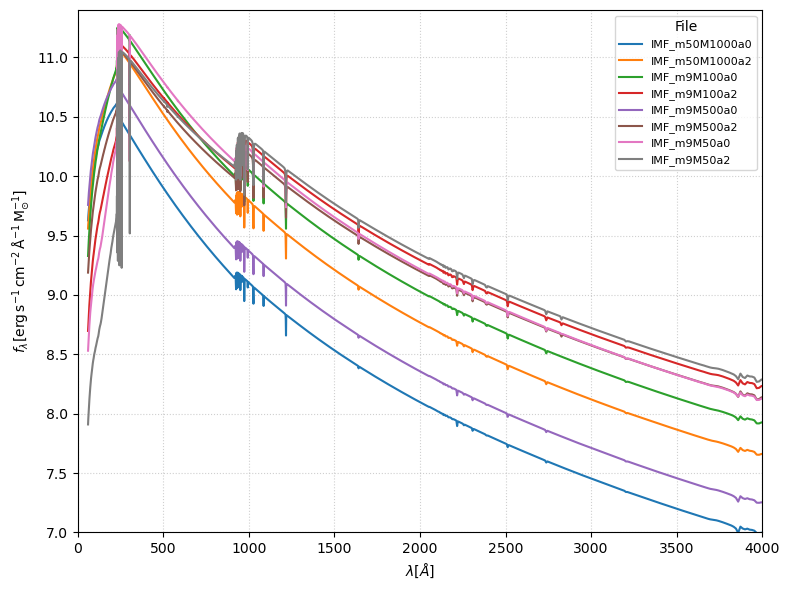

In [5]:
imf_files = sorted([f for f in files if f.startswith("IMF_") and f.endswith(".ascii")])
if not imf_files:
    raise FileNotFoundError("No IMF_*.ascii files found in `files`")

fig, ax = plt.subplots(figsize=(8, 6))

all_x_pos, all_y_pos = True, True

for fn in imf_files:
    path = root / fn
    data = np.loadtxt(path)

    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] < 2:
        raise ValueError(f"{fn} has {data.shape[1]} column(s); expected at least 2")

    x = 3.e18/data[:, 0]
    y = data[:, 1] * 4. * np.pi * 3.e18 / x**2

    all_x_pos &= np.all(x > 0)
    all_y_pos &= np.all(y > 0)

    ax.plot(x, np.log10(y), label=Path(fn).stem)

ax.set_xlabel("$\lambda [\AA]$")
ax.set_ylabel("$f_\lambda {\\rm [erg\, s^{-1}\, cm^{-2}\, \AA^{-1}\, M_{\odot}^{-1}]}$")
ax.grid(True, which="both", ls=":", alpha=0.6)




ax.legend(title="File", fontsize=8)
ax.set_xlim(0,4000)
ax.set_ylim(7, 11.4)
plt.tight_layout()
plt.show()

### How to obtain the galaxy SEDs from the stars and the IMF

In [6]:
massrange = np.array([9,12,15,20,25,30,40,50,60,70,80,100,120,200,300,400,500,1000], dtype=float)
uplim = np.append(massrange[:-1] + np.diff(massrange)/2, 1000+np.diff(massrange)[-1]/2)
lowlim = np.append(9.-np.diff(massrange)[0]/2, massrange[1:] - np.diff(massrange)/2)

In [7]:
uplim

array([  10.5,   13.5,   17.5,   22.5,   27.5,   35. ,   45. ,   55. ,
         65. ,   75. ,   90. ,  110. ,  160. ,  250. ,  350. ,  450. ,
        750. , 1250. ])

In [8]:
lowlim

array([  7.5,  10.5,  13.5,  17.5,  22.5,  27.5,  35. ,  45. ,  55. ,
        65. ,  75. ,  90. , 110. , 160. , 250. , 350. , 450. , 750. ])

In [10]:
uplim[-1]=1250.  # extend the last bin to 1250 Msun to have an upper limit for the last bin
lowlim[0]=7.5   # extend the first bin to 7.5 Msun to have a lower limit for the first bin

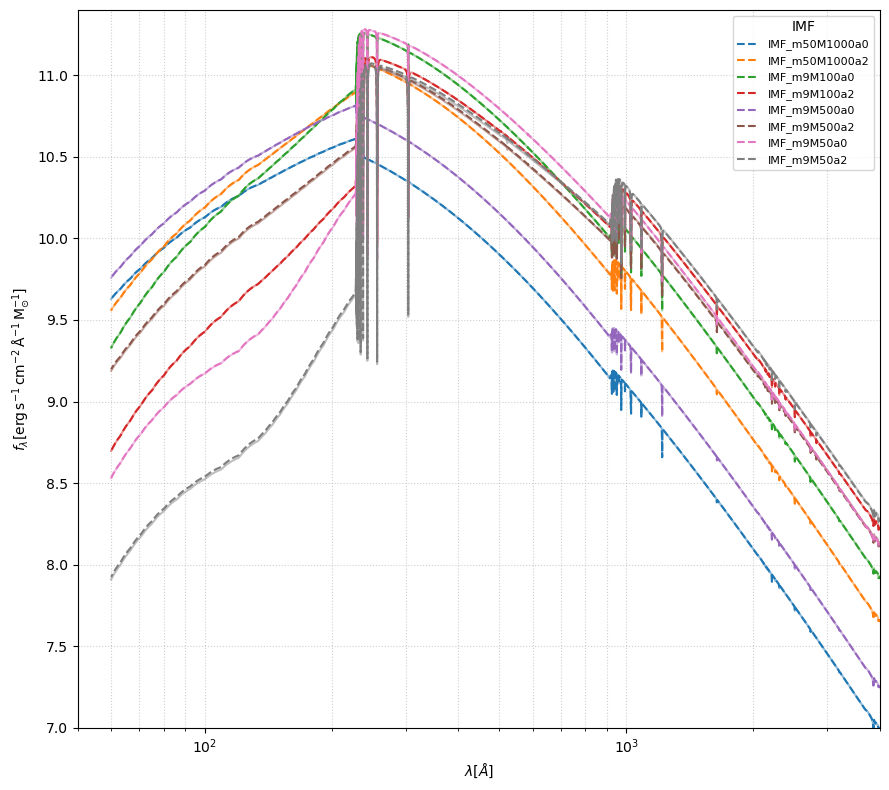

In [ ]:
def star(mass):
    """
    Load the star file for a given mass and return the wavelength and flux arrays.

    Parameters
    ----------
    mass : int or float
        The mass of the star.

    Returns
    -------
    tuple of np.ndarray
        Wavelength and flux arrays.
    """
    m = int(mass)
    star_path = root / f"star_{m}.ascii"
    if not star_path.exists():
        raise FileNotFoundError(f"No star file for mass={mass}: {star_path}")

    arr = np.loadtxt(star_path)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    if arr.shape[1] < 2:
        raise ValueError(f"{star_path.name} has {arr.shape[1]} column(s); expected at least 2")

    return arr[:, 0], arr[:, 1]



def integ(mmin,mmax,alpha):
    """
    Integrate the spectra of stars in the mass range [mmin, mmax] with a given IMF slope alpha.

    Parameters
    ----------
    mmin : float
        Minimum mass of the stars to include in the integration.
    mmax : float
        Maximum mass of the stars to include in the integration.
    alpha : float
        Slope of the IMF. If alpha=2, it will be replaced by 2.35 (Salpeter slope).

    Returns
    -------
    tuple of np.ndarray
        Wavelength and integrated flux arrays.
    """
    totmass = 0
    flux = 0
    if alpha == 2:
        alpha = 2.35
    for i, m in enumerate(massrange):
        if mmin <= m <= mmax:
            w, y = star(m)
            wave = w
            flux += y * m**(-alpha) * (uplim[i] - lowlim[i])  
            totmass +=  m**(-alpha+1) * (uplim[i] - lowlim[i])

    return wave, flux / totmass





# calculate the integrated spectra and plot them (dashed lines) together with the spectra loaded from files (solid lines)
plt.figure(figsize=(9, 8))
# Assign a stable color per file so dashed + solid use the same color
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if not cycle_colors:
    cycle_colors = [plt.cm.tab10(i) for i in range(10)]
color_map = {fn: cycle_colors[i % len(cycle_colors)] for i, fn in enumerate(imf_files)}

# Loop over the IMF files, calculate the integrated spectrum, and plot both the integrated and loaded spectra
for fn in imf_files:
    stem = Path(fn).stem  # e.g. "IMF_m50M1000a0"
    nums = [int(s) for s in "".join(ch if ch.isdigit() else " " for ch in stem).split()]
    if len(nums) != 3:
        raise ValueError(f"Expected 3 numbers in {fn}, got {nums}")
    m1, m2, a = nums  # e.g. 50, 1000, 0

    c = color_map[fn]

    # Dashed: integrated spectrum
    w, f = integ(m1, m2, a)

    if stem == "IMF_m9M100a2":
        out_path = root / f"{stem}.ascii"
        np.savetxt(
            out_path,
            np.column_stack([w, f]),
            fmt="%.8e",
        )

    plt.plot(
        3.e18 / w,  # convert frequency to wavelength
        np.log10(f * w**2 / 3e18 * 4. * np.pi), # convert Eddington flux to flux and from f_nu to f_lambda 
        linestyle="dashed",
        color=c,
        label=stem,
    )

    # Solid: spectrum loaded from file (same color, no extra legend entry)
    path = root / fn
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] < 2:
        raise ValueError(f"{fn} has {data.shape[1]} column(s); expected at least 2")

    x = 3.e18 / data[:, 0] # convert frequency to wavelength
    y = data[:, 1] * 4. * np.pi * 3.e18 / x**2 # convert Eddington flux to flux and from f_nu to f_lambda

    all_x_pos &= np.all(x > 0)
    all_y_pos &= np.all(y > 0)

    plt.plot(x, np.log10(y), color=c, label="_nolegend_",alpha=0.5)

plt.xlabel("$\\lambda [\\AA]$")
plt.ylabel("$f_\\lambda {\\rm [erg\\, s^{-1}\\, cm^{-2}\\, \\AA^{-1}\\, M_{\\odot}^{-1}]}$")
plt.grid(True, which="both", ls=":", alpha=0.6)



plt.legend(title="IMF", fontsize=8)
plt.xscale("log")

plt.xlim(50,4000)
plt.ylim(7, 11.4)
plt.tight_layout()
plt.show()
